In [2]:
#IMPORTING LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [6]:
#1. ESTABLISHING CONNECTION AND IMPORTING DATA TO DATABASE

conn=sqlite3.connect('customer_churn.db')

# reading csv files
accounts = pd.read_csv(r"C:\Users\hp\Desktop\project\Data analyst\Python projects\customer_churn\data\ravenstack_accounts.csv")
subscriptions = pd.read_csv(r"C:\Users\hp\Desktop\project\Data analyst\Python projects\customer_churn\data\ravenstack_subscriptions.csv")
feature_usage = pd.read_csv(r"C:\Users\hp\Desktop\project\Data analyst\Python projects\customer_churn\data\ravenstack_feature_usage.csv")
support_tickets = pd.read_csv(r"C:\Users\hp\Desktop\project\Data analyst\Python projects\customer_churn\data\ravenstack_support_tickets.csv")
churn_events = pd.read_csv(r"C:\Users\hp\Desktop\project\Data analyst\Python projects\customer_churn\data\ravenstack_churn_events.csv")

conn.close()

In [7]:
# INSERTING TABLES INTO DATABASE

accounts.to_sql("accounts", conn, if_exists="replace", index=False)

subscriptions.to_sql("subscriptions", conn, if_exists="replace", index=False)

feature_usage.to_sql("feature_usage", conn, if_exists="replace", index=False)

support_tickets.to_sql("support_tickets", conn, if_exists="replace", index=False)

churn_events.to_sql("churn_events", conn, if_exists="replace", index=False)

600

In [52]:
sql_query = """
    SELECT name
    FROM sqlite_master
    WHERE type='table';
"""

# tables = pd.read_sql(sql_query, conn)

In [14]:
#CREATING PANDAS DATAFRAME
for table_name in tables['name']:
    df=pd.read_sql("Select * from {table_name}",conn)
    globals()[f"df_{table_name}"]=df
    print(f"Created dataframe:df_{table_name}")

Created dataframe:df_accounts
Created dataframe:df_subscriptions
Created dataframe:df_feature_usage
Created dataframe:df_support_tickets
Created dataframe:df_churn_events


In [55]:
# READING COLUMNS FROM THE TABLE

conn=sqlite3.connect('customer_churn.db')
for table_name in tables['name']:
    print(f'table name:{table_name}')
    columns_query=f'PRAGMA table_info({table_name});'
    columns=pd.read_sql(columns_query,conn)
    print("columns")
    print(columns['name'].tolist())
conn.close()    

table name:accounts
columns
['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag']
table name:subscriptions
columns
['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier', 'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag', 'downgrade_flag', 'churn_flag', 'billing_frequency', 'auto_renew_flag']
table name:feature_usage
columns
['usage_id', 'subscription_id', 'usage_date', 'feature_name', 'usage_count', 'usage_duration_secs', 'error_count', 'is_beta_feature']
table name:support_tickets
columns
['ticket_id', 'account_id', 'submitted_at', 'closed_at', 'resolution_time_hours', 'priority', 'first_response_time_minutes', 'satisfaction_score', 'escalation_flag']
table name:churn_events
columns
['churn_event_id', 'account_id', 'churn_date', 'reason_code', 'refund_amount_usd', 'preceding_upgrade_flag', 'preceding_downgrade_flag', 'is_reactivation', 'feedback_text']


In [20]:
#2.DATA CLEANING



df_accounts.head()
# df_accounts.tail()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,0,0
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,0,1
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,0,0
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,1,0
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,0,1


In [18]:
df_accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   account_id       500 non-null    object
 1   account_name     500 non-null    object
 2   industry         500 non-null    object
 3   country          500 non-null    object
 4   signup_date      500 non-null    object
 5   referral_source  500 non-null    object
 6   plan_tier        500 non-null    object
 7   seats            500 non-null    int64 
 8   is_trial         500 non-null    int64 
 9   churn_flag       500 non-null    int64 
dtypes: int64(3), object(7)
memory usage: 39.2+ KB


In [25]:
 df_accounts.describe(include='all')

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
count,500,500,500,500,500,500,500,500.000000,500.000000,500.000000
unique,500,500,5,7,370,5,3,NaN,NaN,NaN
top,A-2e4581,Company_0,DevTools,US,2024-10-27,organic,Pro,NaN,NaN,NaN
freq,1,1,113,291,4,114,178,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.560000,0.194000,0.220000
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.044718,0.395825,0.414661
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.000000,0.000000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.000000,0.000000,0.000000


In [26]:
df_accounts.isnull().sum()

account_id         0
account_name       0
industry           0
country            0
signup_date        0
referral_source    0
plan_tier          0
seats              0
is_trial           0
churn_flag         0
dtype: int64

In [27]:
df_subscriptions.head()

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,0,0,0,1,monthly,1
1,S-0f6f44,A-9b9fe9,2024-06-11,None,Pro,17,833,9996,0,0,0,0,monthly,1
2,S-51c0d1,A-659280,2024-11-25,None,Enterprise,62,0,0,1,1,0,0,annual,0
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,0,0,0,1,monthly,1
4,S-cff5a2,A-ba6516,2024-01-10,None,Enterprise,27,5373,64476,0,0,0,0,monthly,1


In [28]:
df_subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_id    5000 non-null   object
 1   account_id         5000 non-null   object
 2   start_date         5000 non-null   object
 3   end_date           486 non-null    object
 4   plan_tier          5000 non-null   object
 5   seats              5000 non-null   int64 
 6   mrr_amount         5000 non-null   int64 
 7   arr_amount         5000 non-null   int64 
 8   is_trial           5000 non-null   int64 
 9   upgrade_flag       5000 non-null   int64 
 10  downgrade_flag     5000 non-null   int64 
 11  churn_flag         5000 non-null   int64 
 12  billing_frequency  5000 non-null   object
 13  auto_renew_flag    5000 non-null   int64 
dtypes: int64(8), object(6)
memory usage: 547.0+ KB


In [30]:
df_subscriptions.describe(include='all')

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
count,5000,5000,5000,486,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000,5000.000000
unique,5000,500,625,208,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN
top,S-8cec59,A-d4ac0e,2024-12-31,2024-12-31,Enterprise,NaN,NaN,NaN,NaN,NaN,NaN,NaN,monthly,NaN
freq,1,19,45,24,1723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2539,NaN
mean,NaN,NaN,NaN,NaN,NaN,29.852000,2267.749400,27212.992800,0.155600,0.105800,0.043600,0.09720,NaN,0.801000
std,NaN,NaN,NaN,NaN,NaN,23.089771,3421.375348,41056.504178,0.362512,0.307612,0.204224,0.29626,NaN,0.399288
min,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,14.000000,285.000000,3420.000000,0.000000,0.000000,0.000000,0.00000,NaN,1.000000
50%,NaN,NaN,NaN,NaN,NaN,24.000000,931.000000,11172.000000,0.000000,0.000000,0.000000,0.00000,NaN,1.000000
75%,NaN,NaN,NaN,NaN,NaN,40.000000,2786.000000,33432.000000,0.000000,0.000000,0.000000,0.00000,NaN,1.000000


In [31]:
df_subscriptions.isnull().sum()

subscription_id         0
account_id              0
start_date              0
end_date             4514
plan_tier               0
seats                   0
mrr_amount              0
arr_amount              0
is_trial                0
upgrade_flag            0
downgrade_flag          0
churn_flag              0
billing_frequency       0
auto_renew_flag         0
dtype: int64

In [37]:
df_feature_usage.head()

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,0
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,0
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,0
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,0
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,0


In [33]:
df_feature_usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   usage_id             25000 non-null  object
 1   subscription_id      25000 non-null  object
 2   usage_date           25000 non-null  object
 3   feature_name         25000 non-null  object
 4   usage_count          25000 non-null  int64 
 5   usage_duration_secs  25000 non-null  int64 
 6   error_count          25000 non-null  int64 
 7   is_beta_feature      25000 non-null  int64 
dtypes: int64(4), object(4)
memory usage: 1.5+ MB


In [34]:
df_feature_usage.describe(include="all")

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
count,25000,25000,25000,25000,25000.000000,25000.000000,25000.000000,25000.000000
unique,24979,4967,731,40,NaN,NaN,NaN,NaN
top,U-6970d1,S-0896f4,2024-10-11,feature_32,NaN,NaN,NaN,NaN
freq,2,16,53,659,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,10.021000,3042.202880,0.564280,0.101760
std,NaN,NaN,NaN,NaN,3.143729,2056.544615,1.012595,0.302338
min,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,8.000000,1350.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,10.000000,2760.000000,0.000000,0.000000
75%,NaN,NaN,NaN,NaN,12.000000,4400.000000,1.000000,0.000000


In [35]:
df_feature_usage.isnull().sum()

usage_id               0
subscription_id        0
usage_date             0
feature_name           0
usage_count            0
usage_duration_secs    0
error_count            0
is_beta_feature        0
dtype: int64

In [38]:
df_support_tickets.head()

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,0
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,0
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.0,urgent,93,4.0,0
3,T-dfce9a,A-4c56c9,2024-09-08,2024-09-09 23:00:00,47.0,medium,126,5.0,0
4,T-c59f77,A-6f8ad2,2024-11-30,2024-12-01 02:00:00,26.0,medium,8,NaN,0


In [39]:
df_support_tickets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ticket_id                    2000 non-null   object 
 1   account_id                   2000 non-null   object 
 2   submitted_at                 2000 non-null   object 
 3   closed_at                    2000 non-null   object 
 4   resolution_time_hours        2000 non-null   float64
 5   priority                     2000 non-null   object 
 6   first_response_time_minutes  2000 non-null   int64  
 7   satisfaction_score           1175 non-null   float64
 8   escalation_flag              2000 non-null   int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 140.8+ KB


In [40]:
df_support_tickets.describe(include='all')

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
count,2000,2000,2000,2000,2000.000000,2000,2000.000000,1175.000000,2000.000000
unique,2000,492,671,1893,NaN,4,NaN,NaN,NaN
top,T-0024de,A-bb3bd4,2024-12-01,2024-04-28 03:00:00,NaN,urgent,NaN,NaN,NaN
freq,1,11,10,3,NaN,514,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,35.861000,NaN,88.480000,3.981277,0.047500
std,NaN,NaN,NaN,NaN,21.138427,NaN,51.531877,0.809646,0.212759
min,NaN,NaN,NaN,NaN,1.000000,NaN,1.000000,3.000000,0.000000
25%,NaN,NaN,NaN,NaN,17.000000,NaN,43.000000,3.000000,0.000000
50%,NaN,NaN,NaN,NaN,35.000000,NaN,88.000000,4.000000,0.000000
75%,NaN,NaN,NaN,NaN,54.000000,NaN,131.000000,5.000000,0.000000


In [41]:
df_support_tickets.isnull().sum()

ticket_id                        0
account_id                       0
submitted_at                     0
closed_at                        0
resolution_time_hours            0
priority                         0
first_response_time_minutes      0
satisfaction_score             825
escalation_flag                  0
dtype: int64

In [42]:
df_churn_events.head()

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,0,0,0,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,1,0,0,None
2,C-a174be,A-b07346,2024-11-12,budget,0.00,0,0,0,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,0,0,0,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,0,1,1,too expensive


In [43]:
df_churn_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   churn_event_id            600 non-null    object 
 1   account_id                600 non-null    object 
 2   churn_date                600 non-null    object 
 3   reason_code               600 non-null    object 
 4   refund_amount_usd         600 non-null    float64
 5   preceding_upgrade_flag    600 non-null    int64  
 6   preceding_downgrade_flag  600 non-null    int64  
 7   is_reactivation           600 non-null    int64  
 8   feedback_text             452 non-null    object 
dtypes: float64(1), int64(3), object(5)
memory usage: 42.3+ KB


In [44]:
df_churn_events.describe(include='all')

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
count,600,600,600,600,600.000000,600.000000,600.000000,600.000000,452
unique,600,352,311,6,NaN,NaN,NaN,NaN,3
top,C-816288,A-180abf,2024-12-29,features,NaN,NaN,NaN,NaN,too expensive
freq,1,5,7,114,NaN,NaN,NaN,NaN,161
mean,NaN,NaN,NaN,NaN,14.420417,0.205000,0.088333,0.101667,NaN
std,NaN,NaN,NaN,NaN,39.224591,0.404038,0.284016,0.302462,NaN
min,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN
50%,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN
75%,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN


In [45]:
df_churn_events.isnull().sum()

churn_event_id                0
account_id                    0
churn_date                    0
reason_code                   0
refund_amount_usd             0
preceding_upgrade_flag        0
preceding_downgrade_flag      0
is_reactivation               0
feedback_text               148
dtype: int64

In [46]:
df_accounts["account_id"].duplicated().sum()
df_subscriptions["subscription_id"].duplicated().sum()
df_feature_usage["usage_id"].duplicated().sum()
df_support_tickets["ticket_id"].duplicated().sum()
df_churn_events["churn_event_id"].duplicated().sum()

Accounts: 0
Subscriptions: 0
Feature Usage: 0
Support Tickets: 0
Churn Events: 0


In [47]:
#CHECKING FOR DUPLICATES IN PRIMARY KEY

print("Accounts PK:", df_accounts["account_id"].duplicated().sum())

print("Subscriptions PK:", df_subscriptions["subscription_id"].duplicated().sum())

print("Feature Usage PK:", df_feature_usage["usage_id"].duplicated().sum())

print("Support Tickets PK:", df_support_tickets["ticket_id"].duplicated().sum())

print("Churn Events PK:", df_churn_events["churn_event_id"].duplicated().sum())

Accounts PK: 0
Subscriptions PK: 0
Feature Usage PK: 21
Support Tickets PK: 0
Churn Events PK: 0


In [329]:
duplicate_usage = df_feature_usage[
    df_feature_usage["usage_id"].duplicated(keep=False)
].sort_values("usage_id")

duplicate_usage


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
19294,U-0c9318,S-01b2dc,2023-12-11,feature_9,5,1060,3,0
17533,U-0c9318,S-0ffab0,2024-01-30,feature_11,3,1614,0,0
20588,U-13ce5b,S-9b623b,2023-03-26,feature_28,10,2050,1,0
9626,U-13ce5b,S-8b0950,2024-09-10,feature_9,8,824,0,1
18480,U-2103bb,S-7fc49b,2023-04-18,feature_12,9,5022,1,0
10379,U-2103bb,S-ae3270,2024-01-06,feature_3,10,5510,0,0
22,U-25b56c,S-810c27,2024-10-06,feature_20,7,231,0,0
7574,U-25b56c,S-34253c,2023-10-28,feature_20,6,2166,1,0
21376,U-48a4aa,S-93f835,2024-08-24,feature_39,10,4770,0,0
1085,U-48a4aa,S-383ac2,2023-02-12,feature_28,14,7126,0,0


In [59]:
df_accounts['signup_date'] = pd.to_datetime(df_accounts['signup_date'])

df_subscriptions['start_date'] = pd.to_datetime(df_subscriptions['start_date'])
df_subscriptions['end_date'] = pd.to_datetime(df_subscriptions['end_date'])

df_feature_usage['usage_date'] = pd.to_datetime(df_feature_usage['usage_date'])

df_support_tickets['submitted_at'] = pd.to_datetime(df_support_tickets['submitted_at'])
df_support_tickets['closed_at'] = pd.to_datetime(df_support_tickets['closed_at'])

df_churn_events['churn_date'] = pd.to_datetime(df_churn_events['churn_date'])

In [ ]:

#CHECKING IF TABLES HAVE SAME ID OR NOT


In [62]:
missing_accounts = df_subscriptions[
    ~df_subscriptions["account_id"].isin(df_accounts["account_id"])
]

print("Missing account references:", len(missing_accounts))

Missing account references: 0


In [63]:
missing_subscriptions=df_feature_usage[
    ~feature_usage['subscription_id'].isin(df_subscriptions['subscription_id'])
]
print("missing subscriptions references",len(missing_subscriptions))

missing subscriptions references 0


In [64]:
df_accounts.shape[0]

500

In [65]:
df_accounts["industry"].value_counts()

industry
DevTools         113
FinTech          112
Cybersecurity    100
HealthTech        96
EdTech            79
Name: count, dtype: int64

In [66]:
df_accounts["country"].value_counts()

country
US    291
UK     58
IN     49
AU     32
DE     25
CA     23
FR     22
Name: count, dtype: int64

In [67]:
df_accounts["referral_source"].value_counts()

referral_source
organic    114
other      103
ads         98
event       96
partner     89
Name: count, dtype: int64

In [68]:
df_accounts["plan_tier"].value_counts()

plan_tier
Pro           178
Basic         168
Enterprise    154
Name: count, dtype: int64

In [69]:
df_accounts["is_trial"].value_counts()

is_trial
0    403
1     97
Name: count, dtype: int64

In [70]:
df_accounts["churn_flag"].value_counts()

churn_flag
0    390
1    110
Name: count, dtype: int64

In [76]:
#3.FEATURE ENGINEERING AND DATA ANALYSIS

In [77]:
df_accounts.head(3)

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,0,0
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,0,1
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,0,0


In [90]:
# df_accounts.shape
df_subscriptions.shape

(5000, 14)

In [80]:
df_merged = df_subscriptions.merge(
    df_accounts,
    on="account_id",
    how="left"
)

In [83]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   subscription_id    5000 non-null   object        
 1   account_id         5000 non-null   object        
 2   start_date         5000 non-null   datetime64[ns]
 3   end_date           486 non-null    datetime64[ns]
 4   plan_tier_x        5000 non-null   object        
 5   seats_x            5000 non-null   int64         
 6   mrr_amount         5000 non-null   int64         
 7   arr_amount         5000 non-null   int64         
 8   is_trial_x         5000 non-null   int64         
 9   upgrade_flag       5000 non-null   int64         
 10  downgrade_flag     5000 non-null   int64         
 11  churn_flag_x       5000 non-null   int64         
 12  billing_frequency  5000 non-null   object        
 13  auto_renew_flag    5000 non-null   int64         
 14  account_

In [86]:
df_merged.shape  #very very important step to check whether merging didn't created duplicates and if there are then fix them first

(5000, 23)

In [91]:

#DATA ANALYSIS



In [96]:
#1.Churn Rate
churn_rate = df_merged["churn_flag_x"].mean() * 100

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 9.72%


In [98]:
# 2.Retention Rate
retention_rate = (1 - df_merged["churn_flag_x"].mean()) * 100

print(f"Retention Rate: {retention_rate:.2f}%")

Retention Rate: 90.28%


In [101]:
df_merged.head(2)

,subscription_id,account_id,start_date,end_date,plan_tier_x,seats_x,mrr_amount,arr_amount,is_trial_x,upgrade_flag,...,auto_renew_flag,account_name,industry,country,signup_date,referral_source,plan_tier_y,seats_y,is_trial_y,churn_flag_y
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,0,0,...,1,Company_224,DevTools,UK,2023-08-26,event,Pro,1,0,0
1,S-0f6f44,A-9b9fe9,2024-06-11,NaT,Pro,17,833,9996,0,0,...,1,Company_71,EdTech,AU,2023-09-28,other,Basic,5,0,0


In [113]:
# 3.Churn by plan type
churn_by_plan = (
    df_merged
    .groupby("plan_tier_x")["churn_flag_x"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

churn_by_plan

,plan_tier_x,churn_flag_x
0,Enterprise,9.98
1,Pro,9.67
2,Basic,9.49


In [128]:
# 4a Churn by state +sum(revenue) +count of users
country_analysis = (
    df_merged
    .groupby("country")
    .agg(
        churn_rate=("churn_flag_x", "mean"),
        total_revenue=("mrr_amount", "sum"),
        total_customers=("account_id", "nunique")
    )
    .reset_index()
)

country_analysis["churn_rate"] = (
    country_analysis["churn_rate"] * 100
).round(2)

country_analysis

# 4b churn by subscription type + sum(revenue) + count of users

plan_analysis = (
    df_merged
    .groupby("plan_tier_x")
    .agg(
        churn_rate=("churn_flag_x", "mean"),
        total_revenue=("mrr_amount", "sum"),
        total_customers=("account_id", "nunique")
    )
    .reset_index()
)

plan_analysis["churn_rate"] = (
    plan_analysis["churn_rate"] * 100
).round(2)

plan_analysis

,country,churn_flag_x,arr_amount
0,AU,11.217949,3.230692e+06
1,CA,9.677419,2.640896e+06
2,DE,9.478673,2.172614e+06
3,FR,11.848341,3.354290e+06
4,IN,6.626506,2.877892e+06
5,UK,10.847458,2.482314e+06
6,US,9.726444,2.688792e+06


In [129]:
df_merged.columns

Index(['subscription_id', 'account_id', 'start_date', 'end_date',
       'plan_tier_x', 'seats_x', 'mrr_amount', 'arr_amount', 'is_trial_x',
       'upgrade_flag', 'downgrade_flag', 'churn_flag_x', 'billing_frequency',
       'auto_renew_flag', 'account_name', 'industry', 'country', 'signup_date',
       'referral_source', 'plan_tier_y', 'seats_y', 'is_trial_y',
       'churn_flag_y'],
      dtype='object')

In [135]:
# 5.ARPU average revenue per user

arpu=round(df_merged["mrr_amount"].mean(), 2)
print("ARPU",arpu)

ARPU 2267.75


In [164]:
#6 average customer tenure
# count of day users had used our service : cancellation date otherwise current date

today= pd.Timestamp.today()

df_merged['Tenure_days']=np.where(
    df_merged['end_date'].notna(),
    (df_merged['end_date']-df_merged['start_date']).dt.days,
     (today-df_merged['start_date']).dt.days
)

avg_tenure=round(df_merged['Tenure_days'].mean(),0)
print('Average Tenure=',avg_tenure)

Average Tenure= 662.0


In [170]:
#7 Revenue at risk- Revenue lost from churned users

revenue_at_risk=df_merged.loc[
    df_merged["churn_flag_x"] == 1,
    "mrr_amount"
].sum()

print("Revenue at risk=",revenue_at_risk)

Revenue at risk= 1179139


In [178]:
#Revenue at risk by plan

revenue_at_risk_plan = (
    df_merged[df_merged["churn_flag_x"] == 1]
    .groupby("plan_tier_x")["mrr_amount"]
    .sum()
    .sort_values(ascending=False)
)

revenue_at_risk_plan

plan_tier_x
Enterprise    926345
Pro           180271
Basic          72523
Name: mrr_amount, dtype: int64

In [193]:
#8 Escalation rate

escalation_rate = round(
    (df_support_tickets["escalation_flag"]==1).mean() * 100,
    2
)

print(f"Escalation Rate: {escalation_rate}%")




Escalation Rate: 4.75%


In [198]:
# 9. Average complaint rate per user
avg_complaints_per_user = (
    df_support_tickets.groupby("account_id")
    .size()
    .mean()
)

print("Average Complaints Per User:", round(avg_complaints_per_user, 2))

Average Complaints Per User: 4.07


In [201]:
#10 Correlation escaltion vs churn

df_support_churn=df_support_tickets.merge(df_accounts[['account_id','churn_flag']],on='account_id',how='left')

correlation = df_support_churn["escalation_flag"].corr(
    df_support_churn["churn_flag"]
)

print("Correlation between Escalation and Churn:", round(correlation, 3))

Correlation between Escalation and Churn: 0.02


In [216]:
# 11. churn risk - create a column using existing column

# simple rule-based score using your dataset
df_merged["churn_score"] = (
    df_merged["downgrade_flag"] * 30 +
    (1 - df_merged["auto_renew_flag"]) * 25 +
    df_merged["is_trial_x"] * 20 +
    df_merged["upgrade_flag"] * (-10)
)

conditions = [
    (df_merged["churn_score"] < 20),
    (df_merged["churn_score"] >= 20) & (df_merged["churn_score"] < 40),
    (df_merged["churn_score"] >= 40)
]

choices = ["Low", "Medium", "High"]

df_merged["churn_risk"] = np.select(
    conditions,
    choices,
    default="Unknown"
)
df_merged["churn_risk"].value_counts()

churn_risk
Low       3366
Medium    1444
High       190
Name: count, dtype: int64

In [218]:
# Data Visualisation Using Matplotlib

df_visual=df_merged.copy()

In [264]:
df_visual.columns

Index(['subscription_id', 'account_id', 'start_date', 'end_date',
       'plan_tier_x', 'seats_x', 'mrr_amount', 'arr_amount', 'is_trial_x',
       'upgrade_flag', 'downgrade_flag', 'churn_flag_x', 'billing_frequency',
       'auto_renew_flag', 'account_name', 'industry', 'country', 'signup_date',
       'referral_source', 'plan_tier_y', 'seats_y', 'is_trial_y',
       'churn_flag_y', 'Tenure_days', 'churn_score', 'churn_risk'],
      dtype='object')

In [265]:
# 4.1 Monthly churn trend(Time Series KPI)

df_visual["end_date"] = df_visual["end_date"].dt.to_timestamp()

df_visual["churn_month"] = df_visual["end_date"].dt.month_name()

In [271]:
monthly_churn = (
    df_visual[df_visual["churn_flag_x"] == 1]
    .groupby("churn_month")
    .size()
    .reindex([
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December"
    ])
)

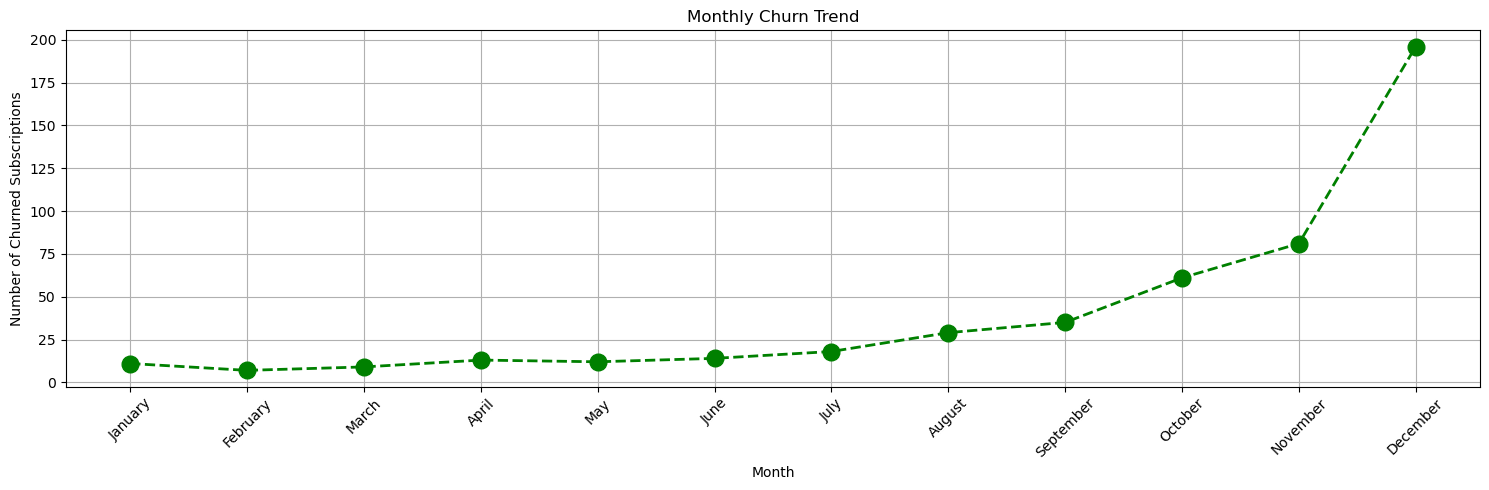

In [280]:
plt.figure(figsize=(15,5))
plt.plot(
    monthly_churn.index,
    monthly_churn.values,
    color='green', marker='o', linestyle='dashed', linewidth=2, markersize=12
)
plt.title("Monthly Churn Trend")
plt.xlabel("Month")
plt.ylabel("Number of Churned Subscriptions")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

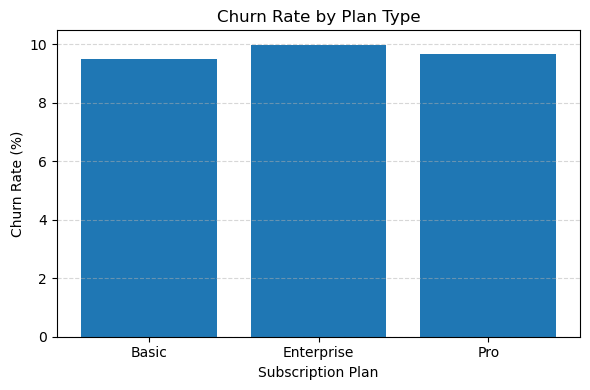

In [286]:
# 4.2 Churn by plan type

churn_by_plan = (
    df_visual
    .groupby("plan_tier_x")["churn_flag_x"]
    .mean()
    .mul(100)
    .round(2)
)
plt.figure(figsize=(6,4))

plt.bar(
    churn_by_plan.index,
    churn_by_plan.values
)

plt.title("Churn Rate by Plan Type")
plt.xlabel("Subscription Plan")
plt.ylabel("Churn Rate (%)")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

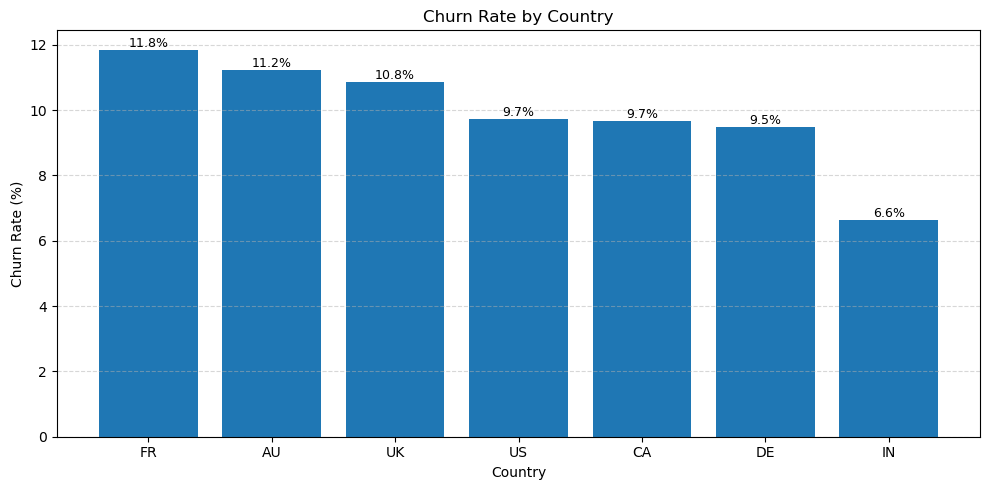

In [291]:
# 4.3 Churn by Country

churn_by_country = (
    df_visual
    .groupby("country")["churn_flag_x"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)
plt.figure(figsize=(10,5))
bars = plt.bar(
    churn_by_country.index,
    churn_by_country.values
)

plt.title("Churn Rate by Country")
plt.xlabel("Country")
plt.ylabel("Churn Rate (%)")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [292]:
# Visulisation using seaborn

In [ ]:
# Encoding

#This is wrong method of encoding as numbers are not assigned based on priority
df_encoded = df_visual[
    [
        "plan_tier_x",
        "billing_frequency",
        "churn_score",
        "churn_flag_x",
        "churn_risk",
        "upgrade_flag",
        "downgrade_flag",
        "auto_renew_flag"
    ]
].copy()

categorical_cols = [
    "plan_tier_x",
    "billing_frequency",
    "churn_risk"
]

for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype("category").cat.codes

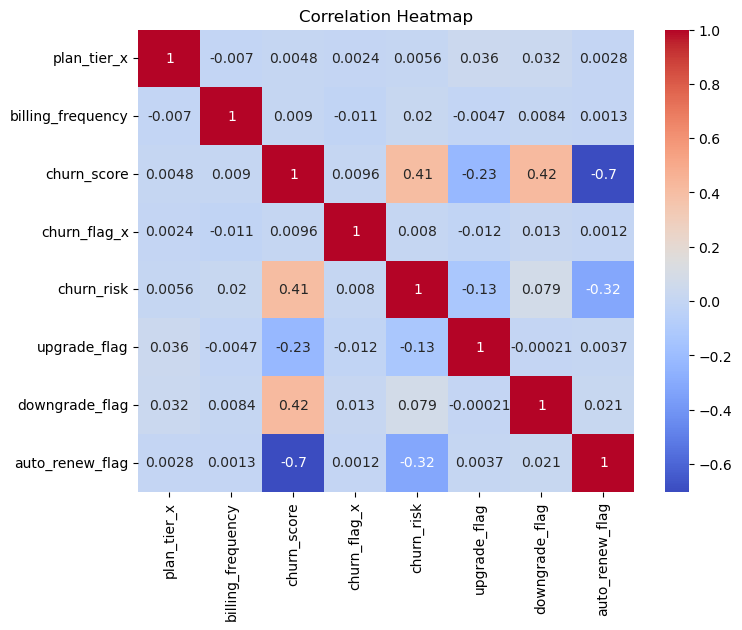

In [293]:
# Heatmap (correlation matrix)

plt.figure(figsize=(8,6))

sns.heatmap(
    df_encoded.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# 0 to 1 - positive correlation
# -1 to 0 - negative correlation

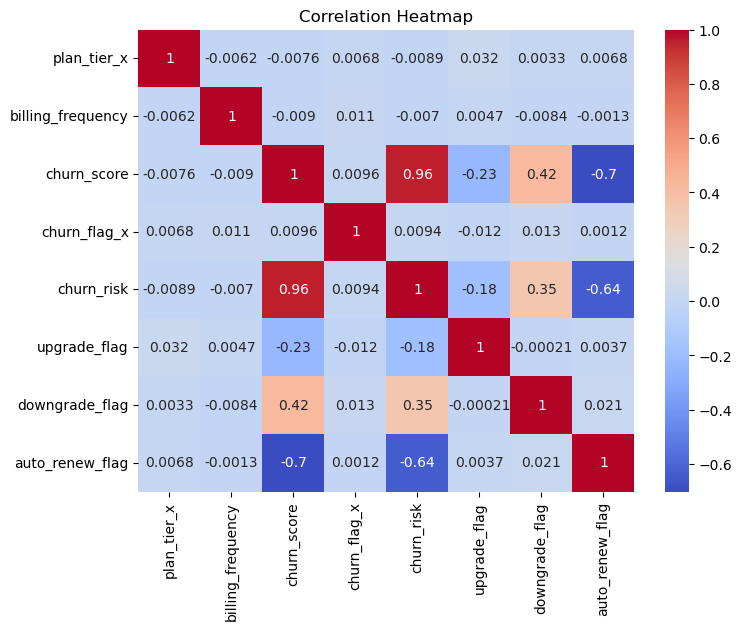

In [299]:
#This is correct method of encoding - based on priority
df_encoded = df_visual[
    [
        "plan_tier_x",
        "billing_frequency",
        "churn_score",
        "churn_flag_x",
        "churn_risk",
        "upgrade_flag",
        "downgrade_flag",
        "auto_renew_flag"
    ]
].copy()

order_mappings = {
    "plan_tier_x" :['Basic','Pro','Enterprise'],
    "billing_frequency":['monthly','annual'],
    "churn_risk":['Low','Medium','High']
}

for col,order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'),categories=order,ordered=True).codes

plt.figure(figsize=(8,6))

sns.heatmap(
    df_encoded.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()
    

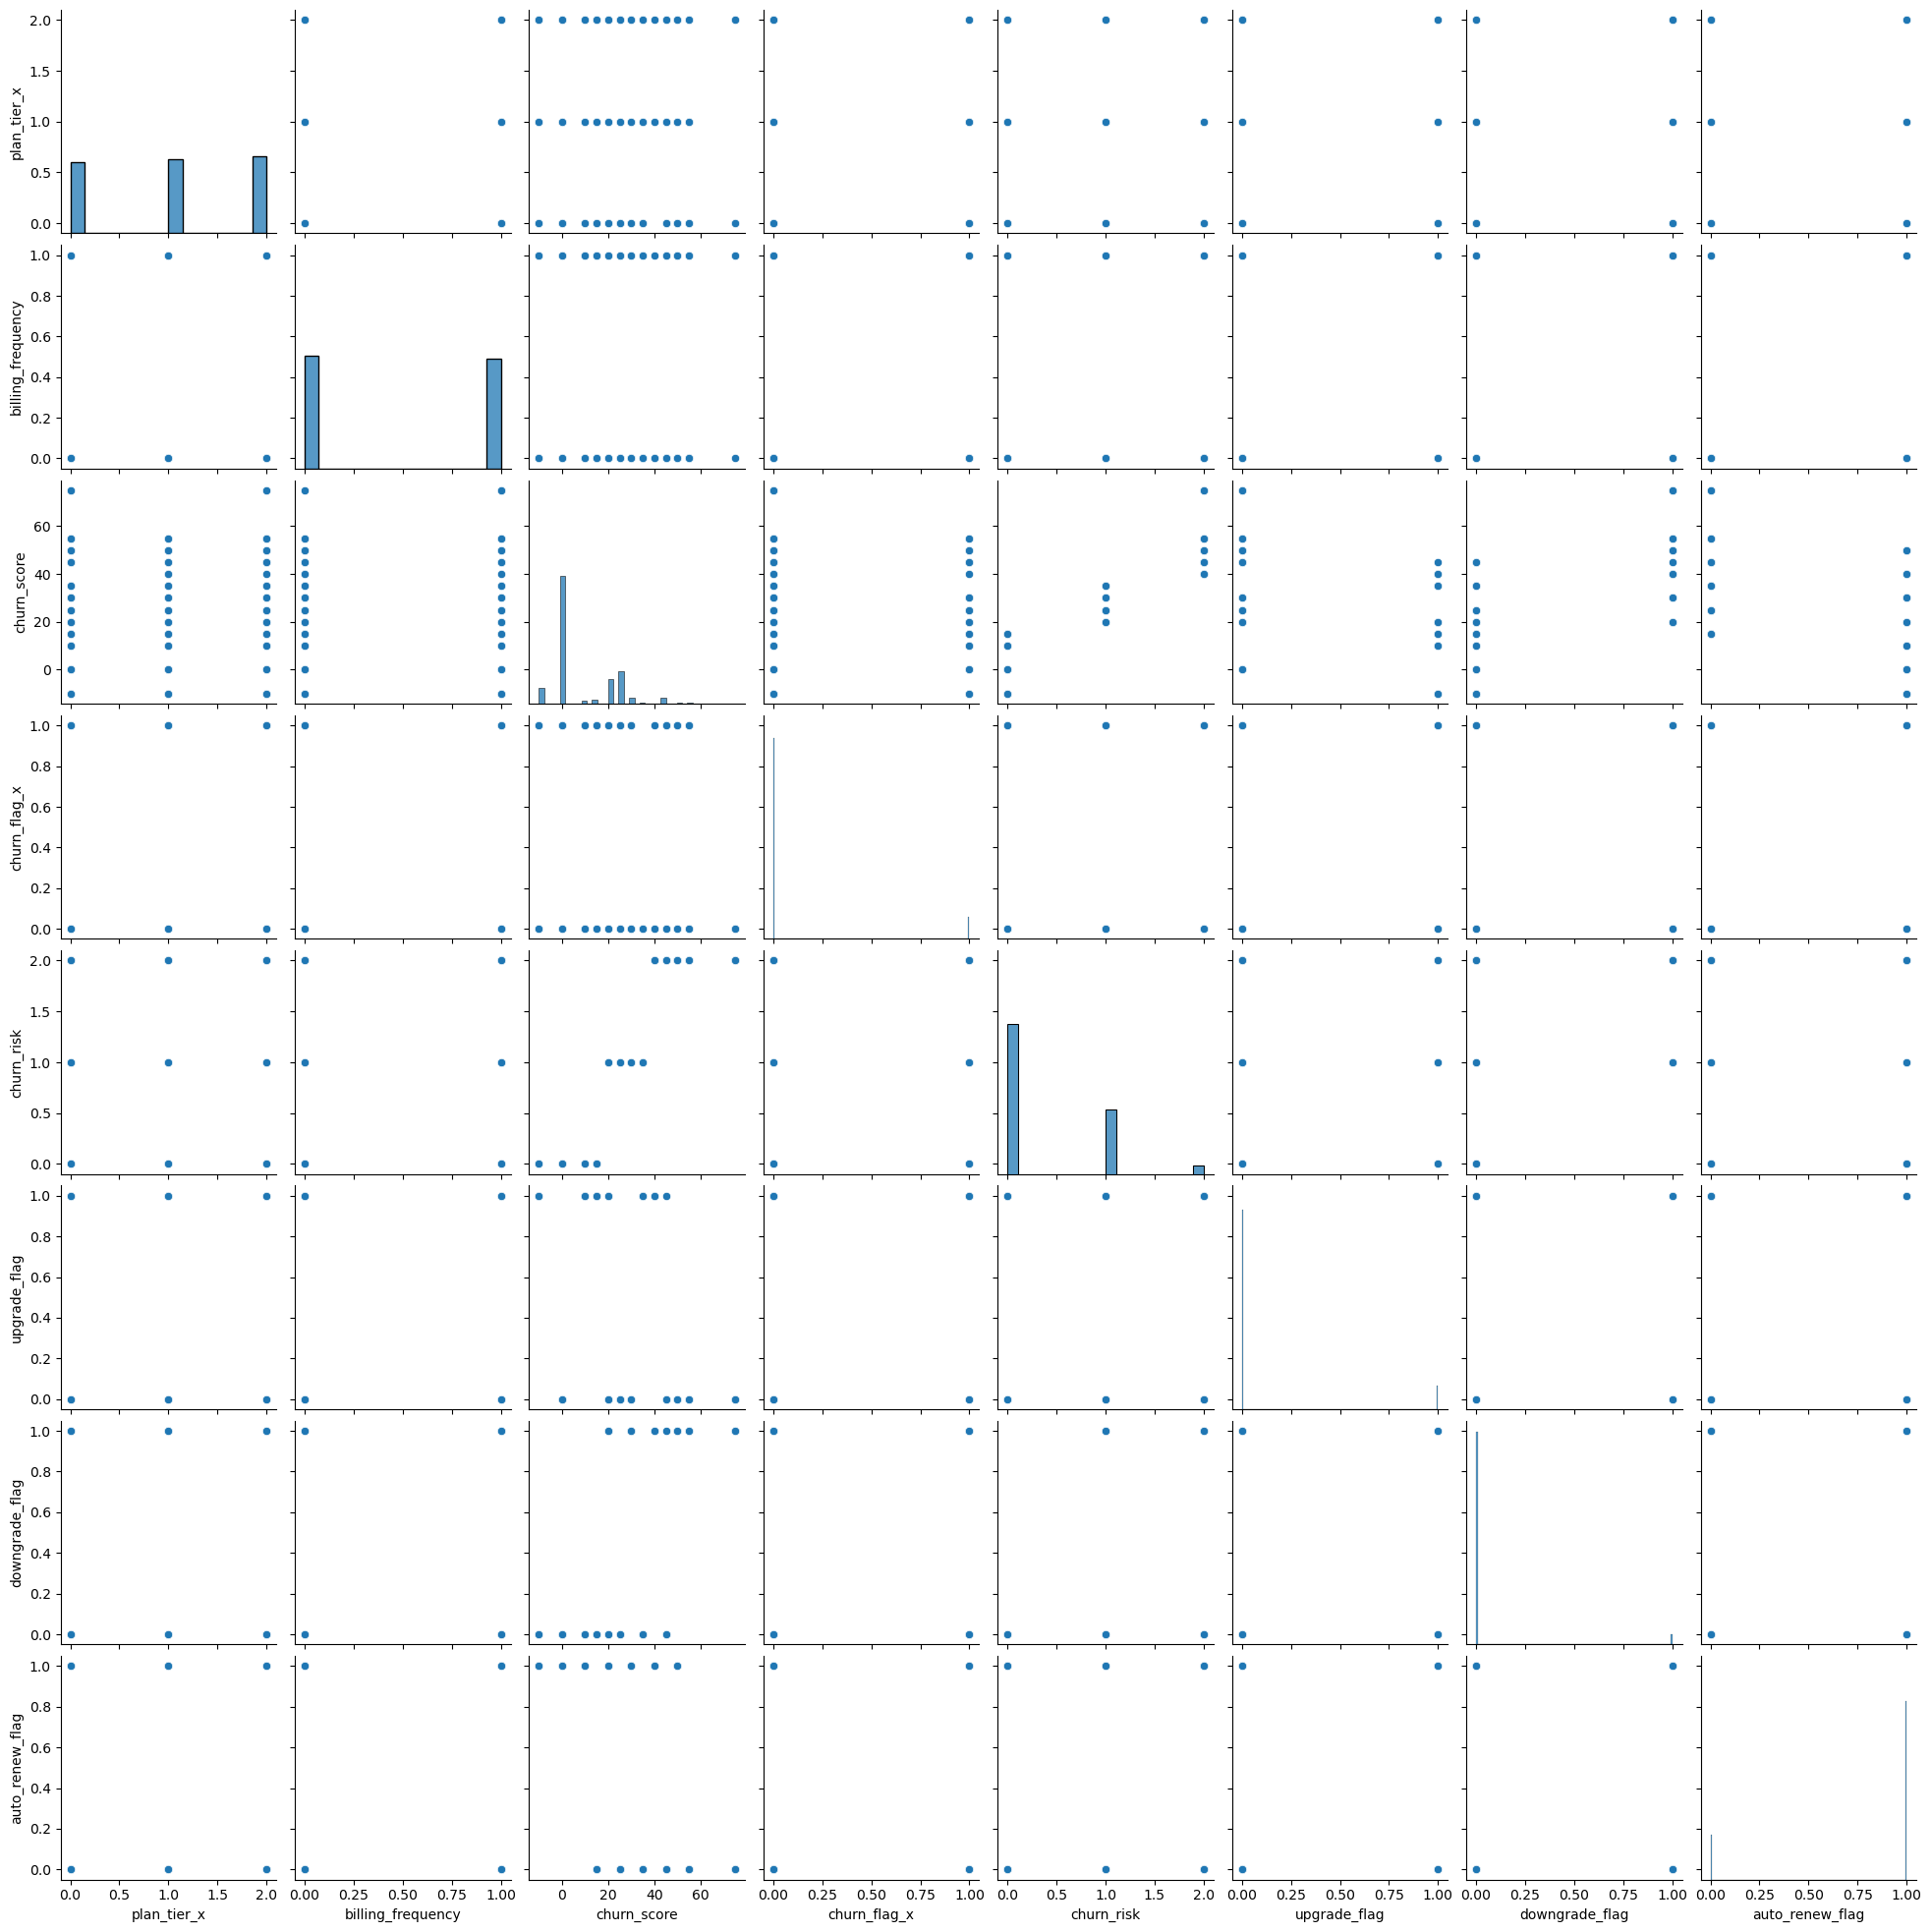

In [300]:
# Pair plot -Relation ship in dataset
sns.pairplot(df_encoded)

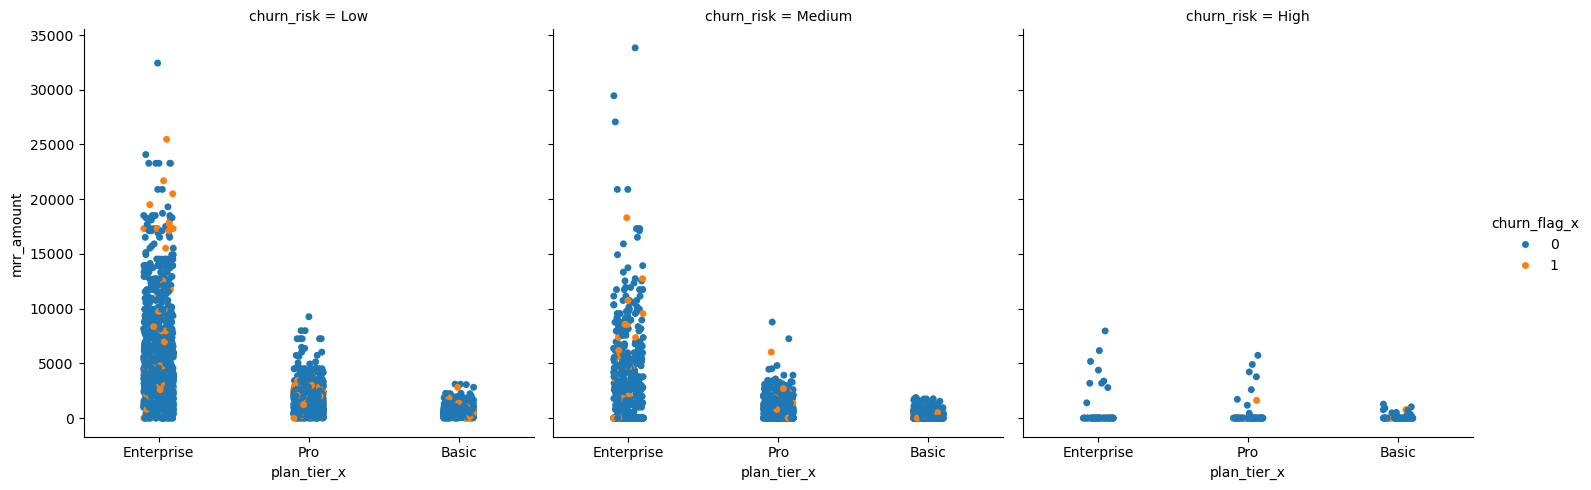

In [302]:
# catplot/facegrid plot - Multidimension comparision 

sns.catplot(data=df_visual,
           x='plan_tier_x',
           y='mrr_amount',
           hue='churn_flag_x',
           col='churn_risk')

In [310]:
# Pivot table

pd.pivot_table( df_visual,
    values='churn_flag_x',
    index='plan_tier_x',
    aggfunc='mean'
)

,churn_flag_x
plan_tier_x,
Basic,0.094881
Enterprise,0.099826
Pro,0.096716


In [313]:
pd.pivot_table( df_visual,
    values=['mrr_amount','account_id','churn_flag_x'],
    index='plan_tier_x',
    aggfunc={
        'mrr_amount':'sum',
        'account_id':'nunique',
        'churn_flag_x':'mean'
    }
)

,account_id,churn_flag_x,mrr_amount
plan_tier_x,,,
Basic,480,0.094881,760437
Enterprise,479,0.099826,8473221
Pro,474,0.096716,2105089


In [357]:
#Top 10 most used feature

top_features = (
    df_feature_usage
    .groupby("feature_name")["usage_count"]
    .sum()
    .sort_values(ascending=False)
)

top_features.head(10)


feature_name
feature_32    6686
feature_15    6621
feature_6     6546
feature_20    6541
feature_34    6536
feature_12    6534
feature_11    6533
feature_2     6525
feature_38    6478
feature_26    6470
Name: usage_count, dtype: int64

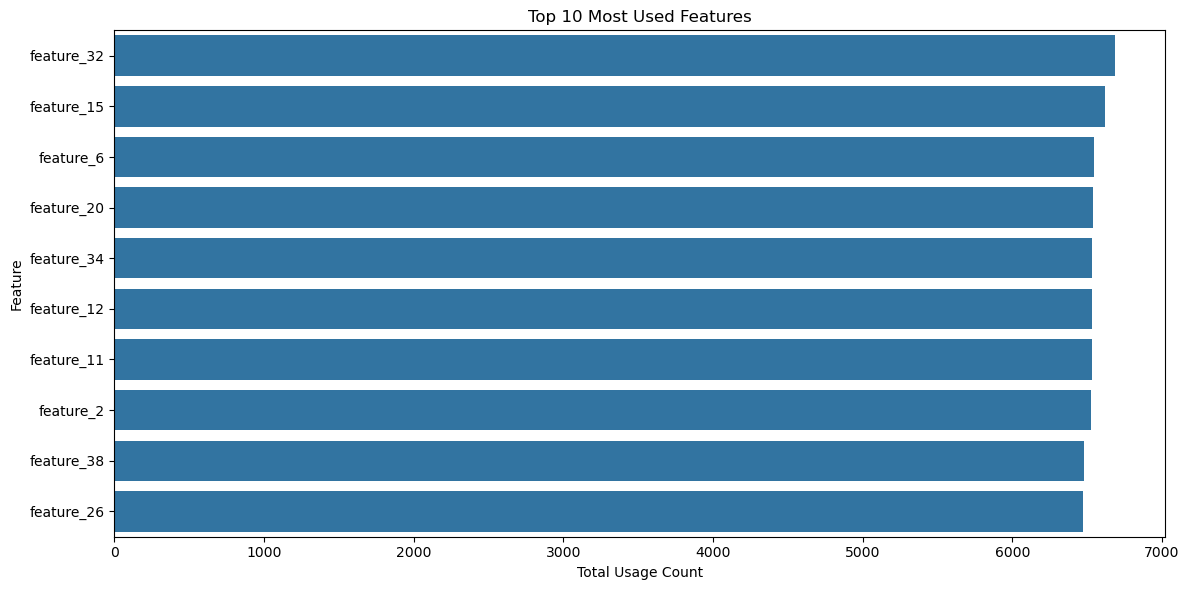

In [361]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_features.head(10).values,
    y=top_features.head(10).index
)

plt.title("Top 10 Most Used Features")
plt.xlabel("Total Usage Count")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [363]:
df_feature_usage.head()

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,0
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,0
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,0
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,0
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,0


In [368]:
#Average usage duration by feature

avg_duration = (
    df_feature_usage
    .groupby("feature_name")["usage_duration_secs"]
    .mean()
    .sort_values(ascending=False)
)

avg_duration.head(10)

feature_name
feature_24    3219.673406
feature_27    3202.729951
feature_8     3150.503356
feature_4     3149.795200
feature_16    3139.081994
feature_11    3130.293935
feature_12    3128.195751
feature_32    3114.288316
feature_40    3109.829308
feature_33    3091.776378
Name: usage_duration_secs, dtype: float64

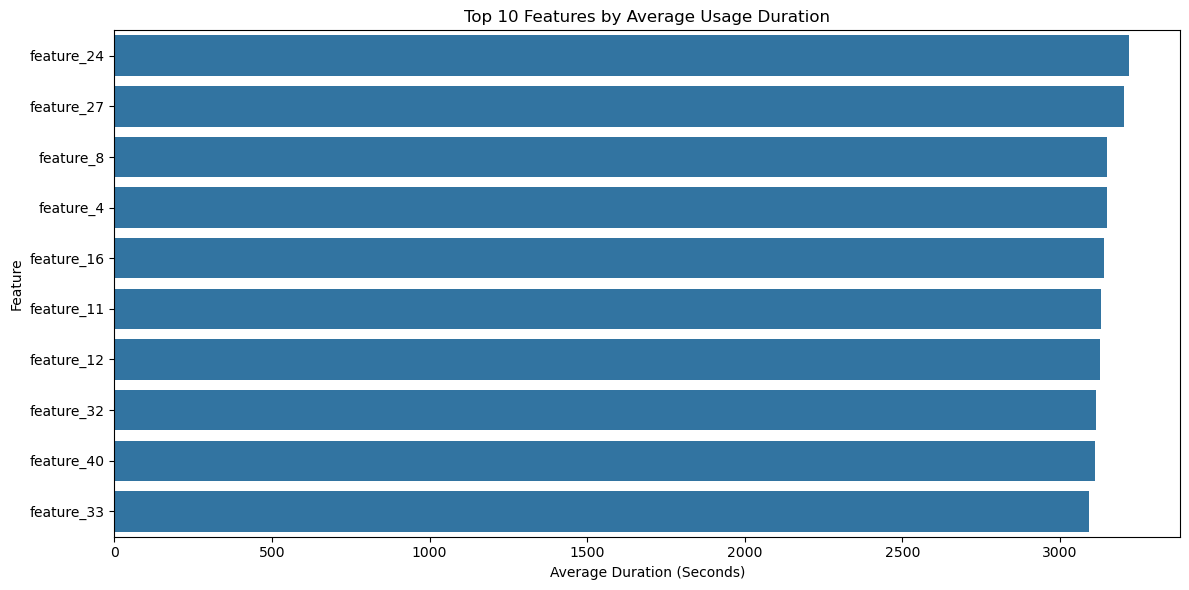

In [372]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=avg_duration.head(10).values,
    y=avg_duration.head(10).index
)

plt.title("Top 10 Features by Average Usage Duration")
plt.xlabel("Average Duration (Seconds)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [393]:
df_feature_usage['is_beta_feature'].unique()


array([0, 1])

In [396]:
#Feature Usage vs Customer Churn

df_usage = df_feature_usage.merge(
    df_subscriptions[["subscription_id", "account_id"]],
    on="subscription_id",
    how="left"
)
df_usage = df_usage.merge(
    df_accounts[["account_id", "churn_flag"]],
    on="account_id",
    how="left"
)

In [397]:
df_usage.head()

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature,account_id,churn_flag
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,0,A-e08cd3,0
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,0,A-c7ffc2,0
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,0,A-bbe56f,0
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,0,A-7f29a7,0
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,0,A-65a46c,0


In [406]:
usage_vs_churn = (
    df_usage
    .groupby("churn_flag")["usage_count"]
    .mean()
)

usage_vs_churn

churn_flag
0    10.018210
1    10.030393
Name: usage_count, dtype: float64

In [424]:
#Active vs Churned

feature_comparison = (
    df_usage
    .groupby(["feature_name", "churn_flag"])["usage_count"]
    .mean()
    .unstack()
)

feature_comparison.columns = ["Active", "Churned"]

feature_comparison

,Active,Churned
feature_name,,
feature_1,10.190476,9.916168
feature_10,10.189189,9.692810
feature_11,10.231733,9.951220
feature_12,9.913043,9.923077
feature_13,9.930380,10.086957
feature_14,9.713043,10.085714
feature_15,10.283925,10.527950
feature_16,10.106776,10.007407
feature_17,9.828740,10.244755


In [425]:
df_support_tickets.head()

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,0
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,0
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.0,urgent,93,4.0,0
3,T-dfce9a,A-4c56c9,2024-09-08,2024-09-09 23:00:00,47.0,medium,126,5.0,0
4,T-c59f77,A-6f8ad2,2024-11-30,2024-12-01 02:00:00,26.0,medium,8,NaN,0


In [428]:
#Average Resolution Time by Priority
resolution_time = (
    df_support_tickets
    .groupby("priority")["resolution_time_hours"]
    .mean()
    .sort_values()
)

resolution_time

priority
urgent    34.568093
medium    35.594705
low       36.346392
high      36.958824
Name: resolution_time_hours, dtype: float64

In [434]:
df_support_analysis = df_support_tickets.merge(
    df_accounts[["account_id", "churn_flag"]],
    on="account_id",
    how="left"
)
df_support_analysis.head()

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag,churn_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,0,1
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,0,0
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.0,urgent,93,4.0,0,1
3,T-dfce9a,A-4c56c9,2024-09-08,2024-09-09 23:00:00,47.0,medium,126,5.0,0,1
4,T-c59f77,A-6f8ad2,2024-11-30,2024-12-01 02:00:00,26.0,medium,8,NaN,0,0


In [439]:
#churn rate by escalation
escalation_churn = (
    df_support_analysis
    .groupby("escalation_flag")["churn_flag"]
    .mean()
    .mul(100)
    .round(2)
)

escalation_churn

escalation_flag
0    21.42
1    25.26
Name: churn_flag, dtype: float64

In [440]:
#escalation rate by priority
escalation_priority = (
    df_support_tickets
    .groupby("priority")["escalation_flag"]
    .mean()
    .mul(100)
    .round(2)
)

escalation_priority

priority
high      4.71
low       4.74
medium    5.09
urgent    4.47
Name: escalation_flag, dtype: float64

In [441]:
df_churn_events.head()

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,0,0,0,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,1,0,0,None
2,C-a174be,A-b07346,2024-11-12,budget,0.00,0,0,0,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,0,0,0,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,0,1,1,too expensive


In [460]:
churn_reason = (
    df_churn_events
    .groupby("reason_code")
    .size()
    .sort_values(ascending=False)
)

churn_reason

reason_code
features      114
budget        104
support       104
unknown        95
competitor     92
pricing        91
dtype: int64

In [466]:
# Refund Analysis
df_churn_events['refund_amount_usd'].sum()

np.float64(8652.25)

In [469]:
#Reactivation Rate
df_churn_events['is_reactivation'].mean()*(100)

np.float64(10.166666666666666)